End-to-End Sales Forecasting & Demand Intelligence System


In [1]:
#Data Manipulation
import pandas as pd 
import numpy as np

#Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#Configure plots
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12, 6)
sns.set_theme(style="whitegrid")

#Ignore warnings
import warnings
warnings.filterwarnings("ignore")

Task 1 — Data Loading, Merging & Deep Exploration

In [2]:
df = pd.read_csv("data/train.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Row ID,9800.0,4900.500000,2829.160653,1.000,2450.750,4900.50,7350.250,9800.00
Postal Code,9789.0,55273.322403,32041.223413,1040.000,23223.000,58103.00,90008.000,99301.00
Sales,9800.0,230.769059,626.651875,0.444,17.248,54.49,210.605,22638.48


In [5]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})
missing.sort_values("Missing Values", ascending=False)

,Missing Values,Percentage
Postal Code,11,0.112245
Row ID,0,0.000000
Order ID,0,0.000000
Order Date,0,0.000000
Ship Mode,0,0.000000
Ship Date,0,0.000000
Customer Name,0,0.000000
Segment,0,0.000000
Country,0,0.000000
Customer ID,0,0.000000


In [6]:
duplicates = df.duplicated().sum()
print(f"Duplicate Records : {duplicates}")

Duplicate Records : 0


In [7]:
df[["Order Date", "Ship Date"]].head(10)


,Order Date,Ship Date
0,08/11/2017,11/11/2017
1,08/11/2017,11/11/2017
2,12/06/2017,16/06/2017
3,11/10/2016,18/10/2016
4,11/10/2016,18/10/2016
5,09/06/2015,14/06/2015
6,09/06/2015,14/06/2015
7,09/06/2015,14/06/2015
8,09/06/2015,14/06/2015
9,09/06/2015,14/06/2015


In [8]:
pd.to_datetime(
    df["Order Date"],
    format="%d/%m/%Y",
    errors="coerce"
).isna().sum()

np.int64(0)

In [9]:
invalid_dates = df[
    pd.to_datetime(
        df["Order Date"],
        format="%d/%m/%Y",
        errors="coerce"
    ).isna()
]

invalid_dates[["Order Date"]].head(20)

,Order Date


In [10]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="mixed",
    dayfirst=True
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    format="mixed",
    dayfirst=True
)

In [11]:
df[["Order Date", "Ship Date"]].dtypes


Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

In [12]:
df[["Order Date", "Ship Date"]].head()

,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


In [13]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()
df["Week"] = df["Order Date"].dt.isocalendar().week.astype(int)
df["Day"] = df["Order Date"].dt.day_name()
df["Quarter"] = df["Order Date"].dt.quarter

In [14]:
def get_season(month):
    if month in[12,1,2]:
        return "Winter"
    elif month in[3,4,5]:
        return "Spring"
    elif month in[6,7,8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)


In [16]:
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

In [18]:
weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
    .sum()
    .reset_index()
)
weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [19]:
monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq = "M"))["Sales"]
    .sum()
    .reset_index()
)
monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


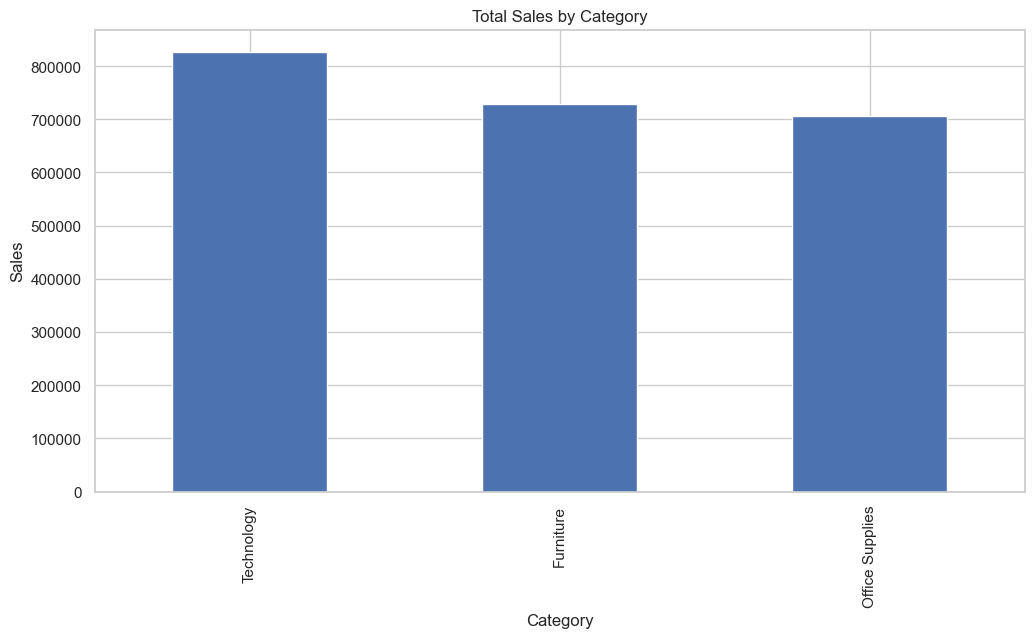

In [20]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)
category_sales.plot(kind="bar")
plt.title("Total Sales by Category")
plt.ylabel("Sales")
plt.show()

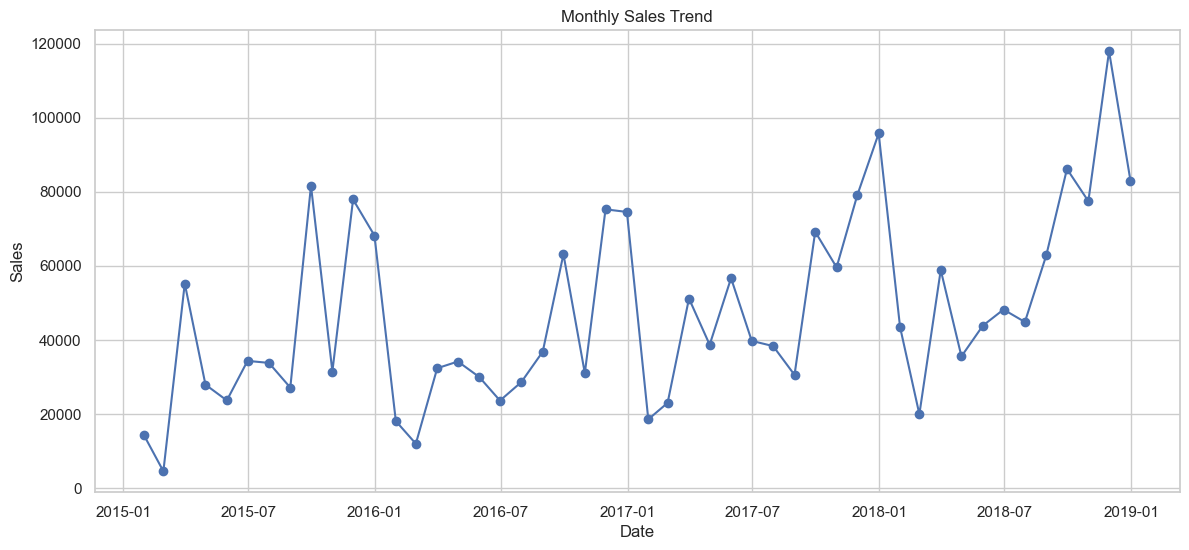

In [22]:
plt.figure(figsize=(14,6))
plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker = "o"
)
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

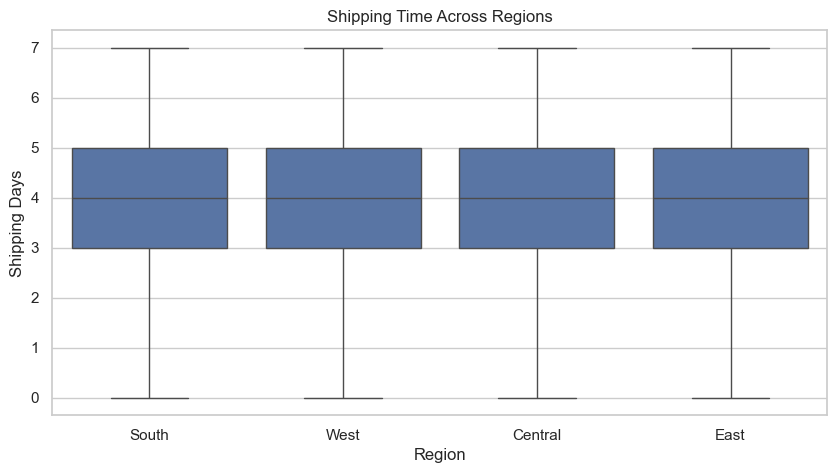

In [25]:
plt.figure(figsize=(10,5))
sns.boxplot(
    x="Region",
    y="Shipping Days",
    data = df
)
plt.title("Shipping Time Across Regions")
plt.show()

Buisness Questions


# 1. 
category_sales

Technology generates the highest overall revenue, followed by Furniture and Office Supplies.

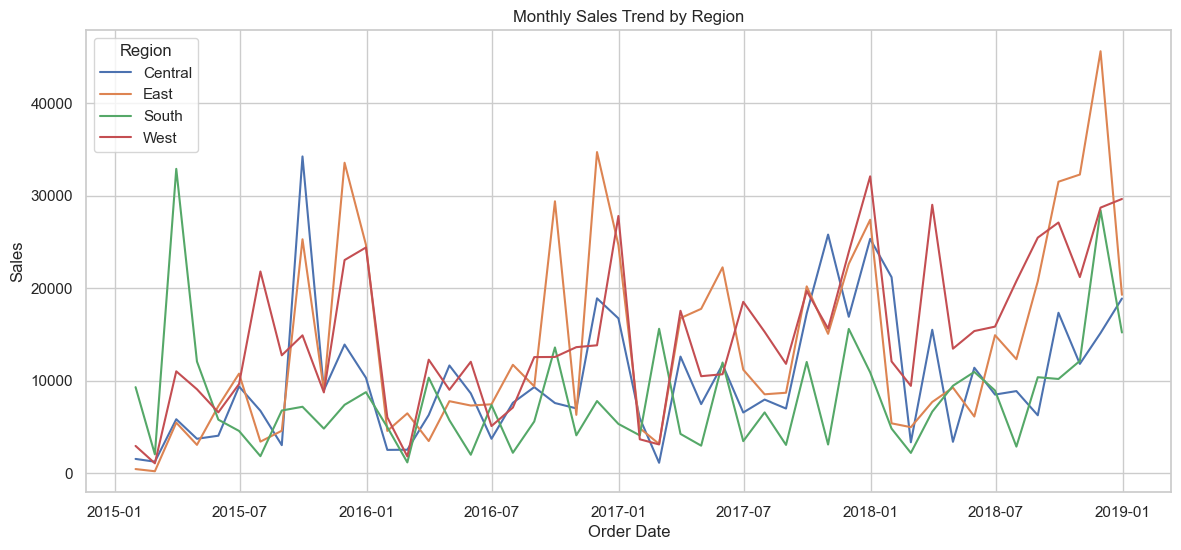

In [ ]:
# q2 
regional_monthly = (
    df.groupby([
        pd.Grouper(key="Order Date", freq ="M"),
        "Region"
    ])["Sales"]
    .sum()
    .reset_index()
)
plt.figure(figsize=(14,6))
sns.lineplot(
    data = regional_monthly,
    x ="Order Date",
    y = "Sales",
    hue = "Region"
)
plt.title("Monthly Sales Trend by Region")
plt.show()


The west region demonstrates the most consistent upward sales trend over the four-year period.

In [28]:
#Q3
df.groupby("Region")["Shipping Days"].mean().sort_values()

Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping Days, dtype: float64

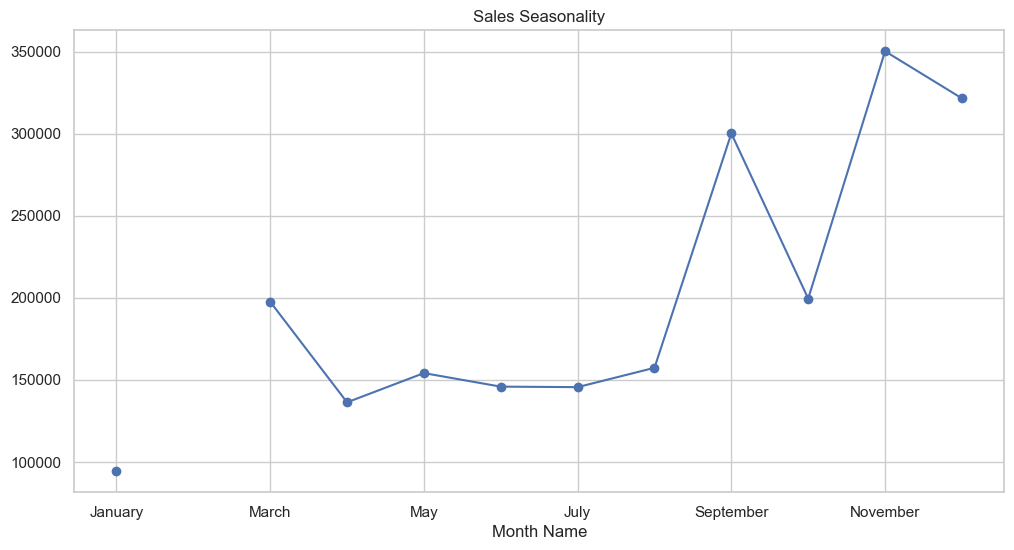

In [29]:
#Q4
seasonality = (
    df.groupby("Month Name")["Sales"]
    .sum()
    .reindex([
        "January","Feburary","March","April","May","June","July","August",
        "September","October","November","December"
    ])
)
seasonality.plot(marker="o")
plt.title("Sales Seasonality")
plt.show()

Task 1 Summary

-Successfully loaded and cleaned the Superstore Sales dataset.

-Converted data columns into datetime format.

-Created additional temporal features including Year, Month, Week, Quarter, Day, and Season.

-Calculated shipping duration for each transaction.

-Aggregated sales into weekly and monthly levels for future forecasting.

-Identified sales distribution across product categories and regions.

-Examoned shipping performance across different regions.

-Explored monthly sales trends and seasonal behaviour.